In [4]:
# Week 2: Greeks and Option Pricing
# Building upon the Option class from Week 1

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

class Option:
    def __init__(self, option_type, strike, spot, premium):
        if option_type not in ['call', 'put']:
            raise ValueError("option_type must be 'call' or 'put'")
        self.option_type = option_type
        self.strike = strike
        self.spot = spot
        self.premium = premium
    
    def payoff_at_expiry(self, future_spot):
        """Calculate payoff for the buyer at expiry"""
        if self.option_type == 'call':
            intrinsic = max(0, future_spot - self.strike)
        elif self.option_type == 'put':
            intrinsic = max(0, self.strike - future_spot)
        return intrinsic - self.premium
    
    def seller_payoff(self, future_spot):
        """Calculate payoff for the seller at expiry"""
        return -self.payoff_at_expiry(future_spot)
    
    @staticmethod
    def black_scholes_price(S, K, T, r, sigma, option_type='call'):
        """
        Calculate option price using Black-Scholes formula
        
        Parameters:
        S : float - Current spot price
        K : float - Strike price
        T : float - Time to expiry (in years)
        r : float - Risk-free interest rate (annualized)
        sigma : float - Volatility (annualized)
        option_type : str - 'call' or 'put'
        
        Returns:
        float - Option price
        """
        # Calculate d1 and d2
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        
        if option_type == 'call':
            # Call price: C = S*N(d1) - K*e^(-r*T)*N(d2)
            price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        elif option_type == 'put':
            # Put price: P = K*e^(-r*T)*N(-d2) - S*N(-d1)
            price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        else:
            raise ValueError("option_type must be 'call' or 'put'")
        
        return price
    
    def black_scholes_price_instance(self, T, r, sigma):
        """
        Calculate Black-Scholes price for this option instance
        
        Parameters:
        T : float - Time to expiry (in years)
        r : float - Risk-free interest rate
        sigma : float - Volatility
        
        Returns:
        float - Black-Scholes theoretical price
        """
        return self.black_scholes_price(self.spot, self.strike, T, r, sigma, self.option_type)
    
    @staticmethod
    def _calculate_d1_d2(S, K, T, r, sigma):
        """Helper method to calculate d1 and d2"""
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return d1, d2
    
    @staticmethod
    def delta(S, K, T, r, sigma, option_type='call'):
        """
        Calculate Delta - sensitivity of option price to changes in spot price
        
        Delta (Call) = N(d1)
        Delta (Put) = N(d1) - 1
        """
        d1, _ = Option._calculate_d1_d2(S, K, T, r, sigma)
        if option_type == 'call':
            return norm.cdf(d1)
        else:
            return norm.cdf(d1) - 1
    
    @staticmethod
    def gamma(S, K, T, r, sigma, option_type='call'):
        """
        Calculate Gamma - rate of change of delta
        
        Gamma = N'(d1) / (S * σ * √T)
        (Same for calls and puts)
        """
        d1, _ = Option._calculate_d1_d2(S, K, T, r, sigma)
        return norm.pdf(d1) / (S * sigma * np.sqrt(T))
    
    @staticmethod
    def vega(S, K, T, r, sigma, option_type='call'):
        """
        Calculate Vega - sensitivity to changes in volatility
        
        Vega = S * N'(d1) * √T / 100
        (Same for calls and puts, divided by 100 for 1% change in volatility)
        """
        d1, _ = Option._calculate_d1_d2(S, K, T, r, sigma)
        return S * norm.pdf(d1) * np.sqrt(T) / 100
    
    @staticmethod
    def theta(S, K, T, r, sigma, option_type='call'):
        """
        Calculate Theta - sensitivity to passage of time (time decay)
        
        For Call: θ = -S*N'(d1)*σ/(2√T) - r*K*e^(-r*T)*N(d2)
        For Put: θ = -S*N'(d1)*σ/(2√T) + r*K*e^(-r*T)*N(-d2)
        """
        d1, d2 = Option._calculate_d1_d2(S, K, T, r, sigma)
        
        # First term (same for calls and puts)
        first_term = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
        
        if option_type == 'call':
            # Second term for calls
            second_term = -r * K * np.exp(-r * T) * norm.cdf(d2)
        else:
            # Second term for puts
            second_term = r * K * np.exp(-r * T) * norm.cdf(-d2)
        
        return first_term + second_term
    
    def delta_instance(self, T, r, sigma):
        """Calculate delta for this option instance"""
        return self.delta(self.spot, self.strike, T, r, sigma, self.option_type)
    
    def gamma_instance(self, T, r, sigma):
        """Calculate gamma for this option instance"""
        return self.gamma(self.spot, self.strike, T, r, sigma, self.option_type)
    
    def vega_instance(self, T, r, sigma):
        """Calculate vega for this option instance"""
        return self.vega(self.spot, self.strike, T, r, sigma, self.option_type)
    
    def theta_instance(self, T, r, sigma):
        """Calculate theta for this option instance"""
        return self.theta(self.spot, self.strike, T, r, sigma, self.option_type)

In [2]:
# Task 1: Test Black-Scholes formulas

# Define parameters
S = 100  # Current spot price
K = 100  # Strike price
T = 1.0  # 1 year to expiry
r = 0.05  # 5% risk-free rate
sigma = 0.2  # 20% volatility

# Calculate Black-Scholes prices
call_price = Option.black_scholes_price(S, K, T, r, sigma, 'call')
put_price = Option.black_scholes_price(S, K, T, r, sigma, 'put')

print("=" * 60)
print("BLACK-SCHOLES OPTION PRICING")
print("=" * 60)
print(f"\nInput Parameters:")
print(f"  Spot Price (S):          ${S}")
print(f"  Strike Price (K):        ${K}")
print(f"  Time to Expiry (T):      {T} year(s)")
print(f"  Risk-free Rate (r):      {r*100}%")
print(f"  Volatility (σ):          {sigma*100}%")

print(f"\nBlack-Scholes Prices:")
print(f"  Call Option Price:       ${call_price:.4f}")
print(f"  Put Option Price:        ${put_price:.4f}")

# Verify put-call parity: C - P = S - K*e^(-r*T)
theoretical_diff = S - K * np.exp(-r * T)
actual_diff = call_price - put_price
print(f"\nPut-Call Parity Check:")
print(f"  C - P (actual):          ${actual_diff:.4f}")
print(f"  S - K*e^(-r*T):          ${theoretical_diff:.4f}")
print(f"  Difference:              ${abs(actual_diff - theoretical_diff):.6f}")

# Test with different parameters
print("\n" + "=" * 60)
print("SENSITIVITY ANALYSIS")
print("=" * 60)

# 1. Different volatilities
print(f"\nCall Price at Different Volatilities (S={S}, K={K}, T={T}, r={r}):")
volatilities = [0.10, 0.15, 0.20, 0.25, 0.30]
for vol in volatilities:
    price = Option.black_scholes_price(S, K, T, r, vol, 'call')
    print(f"  σ = {vol*100:5.1f}%  →  Call Price: ${price:7.4f}")

# 2. Different time to expiry
print(f"\nCall Price at Different Times to Expiry (S={S}, K={K}, r={r}, σ={sigma}):")
times = [0.1, 0.25, 0.5, 1.0, 2.0]
for t in times:
    price = Option.black_scholes_price(S, K, t, r, sigma, 'call')
    print(f"  T = {t:4.2f} years  →  Call Price: ${price:7.4f}")

# 3. Different spot prices
print(f"\nCall and Put Prices at Different Spot Prices (K={K}, T={T}, r={r}, σ={sigma}):")
spot_prices = [90, 95, 100, 105, 110]
for spot in spot_prices:
    call = Option.black_scholes_price(spot, K, T, r, sigma, 'call')
    put = Option.black_scholes_price(spot, K, T, r, sigma, 'put')
    print(f"  S = ${spot:3.0f}  →  Call: ${call:7.4f}  |  Put: ${put:7.4f}")

BLACK-SCHOLES OPTION PRICING

Input Parameters:
  Spot Price (S):          $100
  Strike Price (K):        $100
  Time to Expiry (T):      1.0 year(s)
  Risk-free Rate (r):      5.0%
  Volatility (σ):          20.0%

Black-Scholes Prices:
  Call Option Price:       $10.4506
  Put Option Price:        $5.5735

Put-Call Parity Check:
  C - P (actual):          $4.8771
  S - K*e^(-r*T):          $4.8771
  Difference:              $0.000000

SENSITIVITY ANALYSIS

Call Price at Different Volatilities (S=100, K=100, T=1.0, r=0.05):
  σ =  10.0%  →  Call Price: $ 6.8050
  σ =  15.0%  →  Call Price: $ 8.5917
  σ =  20.0%  →  Call Price: $10.4506
  σ =  25.0%  →  Call Price: $12.3360
  σ =  30.0%  →  Call Price: $14.2313

Call Price at Different Times to Expiry (S=100, K=100, r=0.05, σ=0.2):
  T = 0.10 years  →  Call Price: $ 2.7737
  T = 0.25 years  →  Call Price: $ 4.6150
  T = 0.50 years  →  Call Price: $ 6.8887
  T = 1.00 years  →  Call Price: $10.4506
  T = 2.00 years  →  Call Price: $16.1

In [5]:
# Task 2: Test Greek Calculations

# Parameters for testing
S = 100
K = 100
T = 0.5
r = 0.05
sigma = 0.2

print("=" * 70)
print("GREEKS - OPTION SENSITIVITY MEASURES")
print("=" * 70)
print(f"\nParameters: S=${S}, K=${K}, T={T} years, r={r*100}%, σ={sigma*100}%\n")

# Test Greeks for a call option
print("CALL OPTION GREEKS:")
print("-" * 70)
call_delta = Option.delta(S, K, T, r, sigma, 'call')
call_gamma = Option.gamma(S, K, T, r, sigma, 'call')
call_vega = Option.vega(S, K, T, r, sigma, 'call')
call_theta = Option.theta(S, K, T, r, sigma, 'call')

print(f"  Delta:  {call_delta:8.4f}   (Option price changes ${call_delta:.4f} per $1 change in spot)")
print(f"  Gamma:  {call_gamma:8.4f}   (Delta changes {call_gamma:.4f} per $1 change in spot)")
print(f"  Vega:   {call_vega:8.4f}   (Option price changes ${call_vega:.4f} per 1% change in volatility)")
print(f"  Theta:  {call_theta:8.4f}   (Option loses ${-call_theta:.4f} per day from time decay)")

# Test Greeks for a put option
print(f"\nPUT OPTION GREEKS:")
print("-" * 70)
put_delta = Option.delta(S, K, T, r, sigma, 'put')
put_gamma = Option.gamma(S, K, T, r, sigma, 'put')
put_vega = Option.vega(S, K, T, r, sigma, 'put')
put_theta = Option.theta(S, K, T, r, sigma, 'put')

print(f"  Delta:  {put_delta:8.4f}   (Option price changes ${put_delta:.4f} per $1 change in spot)")
print(f"  Gamma:  {put_gamma:8.4f}   (Delta changes {put_gamma:.4f} per $1 change in spot)")
print(f"  Vega:   {put_vega:8.4f}   (Option price changes ${put_vega:.4f} per 1% change in volatility)")
print(f"  Theta:  {put_theta:8.4f}   (Option loses ${-put_theta:.4f} per day from time decay)")

print(f"\nObservations:")
print(f"  • Gamma is the same for calls and puts (both positive)")
print(f"  • Vega is the same for calls and puts (both positive)")
print(f"  • Delta differs: Call({call_delta:.4f}) + Put({put_delta:.4f}) = {call_delta + put_delta:.4f} ≈ 1 - e^(-r*T)")
print(f"  • Theta is typically negative for long options (time decay works against you)")

GREEKS - OPTION SENSITIVITY MEASURES

Parameters: S=$100, K=$100, T=0.5 years, r=5.0%, σ=20.0%

CALL OPTION GREEKS:
----------------------------------------------------------------------
  Delta:    0.5977   (Option price changes $0.5977 per $1 change in spot)
  Gamma:    0.0274   (Delta changes 0.0274 per $1 change in spot)
  Vega:     0.2736   (Option price changes $0.2736 per 1% change in volatility)
  Theta:   -8.1160   (Option loses $8.1160 per day from time decay)

PUT OPTION GREEKS:
----------------------------------------------------------------------
  Delta:   -0.4023   (Option price changes $-0.4023 per $1 change in spot)
  Gamma:    0.0274   (Delta changes 0.0274 per $1 change in spot)
  Vega:     0.2736   (Option price changes $0.2736 per 1% change in volatility)
  Theta:   -3.2394   (Option loses $3.2394 per day from time decay)

Observations:
  • Gamma is the same for calls and puts (both positive)
  • Vega is the same for calls and puts (both positive)
  • Delta differs

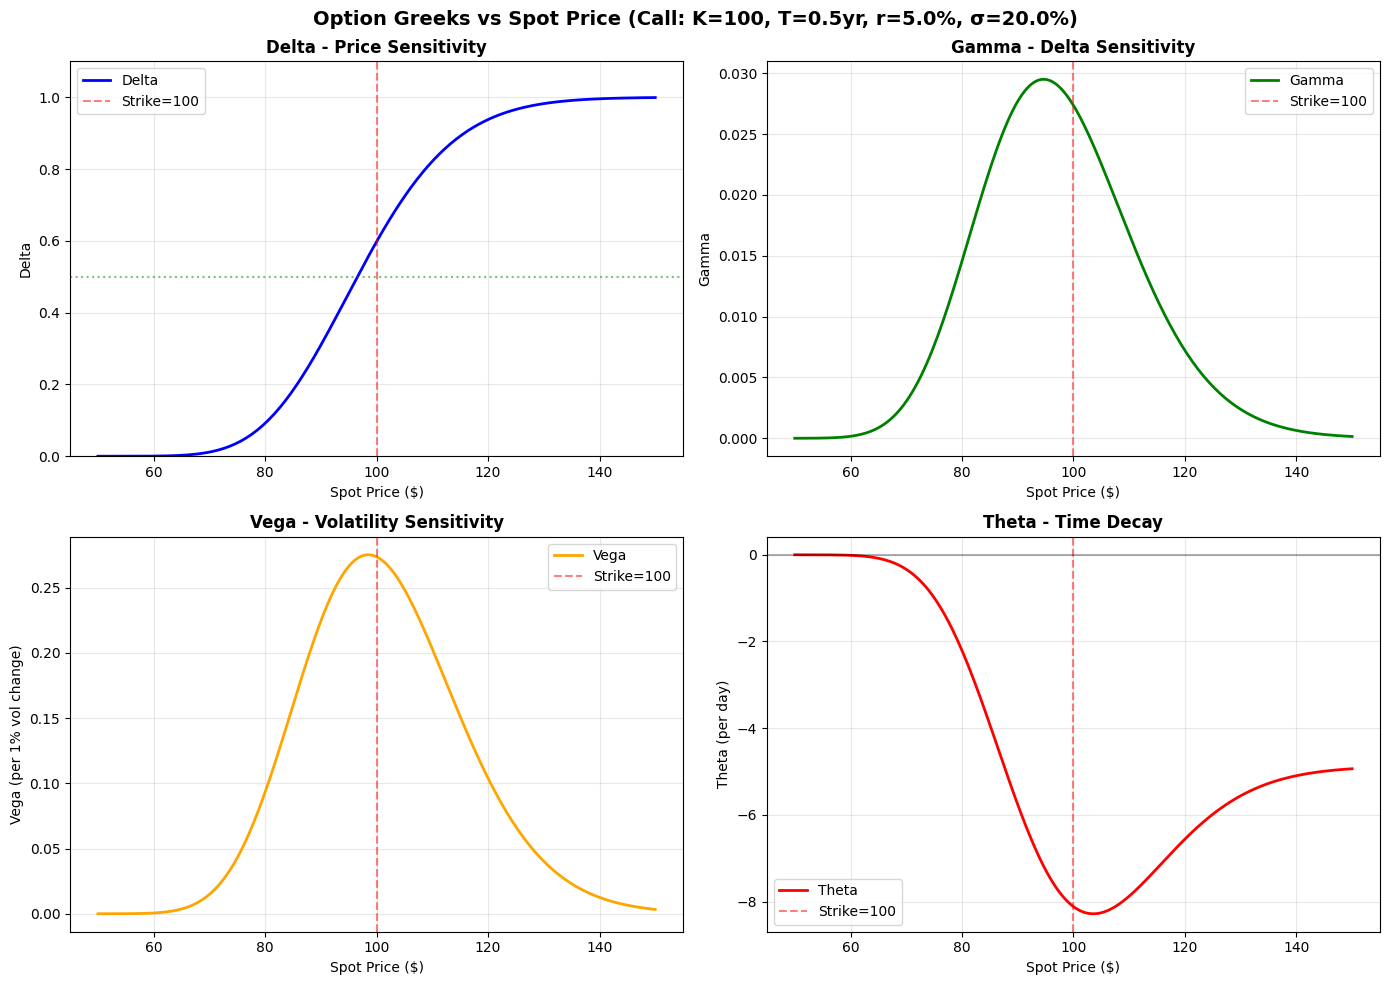


Greeks Interpretation:
----------------------------------------------------------------------
• DELTA: How much option price changes with $1 spot move
  - Call: 0 (OTM) to 1 (ITM)
  - At strike, ~0.5 (at-the-money)

• GAMMA: Curvature of the price-delta relationship
  - Highest at-the-money
  - Exposes you to 'gamma risk' or 'gamma profit'

• VEGA: Sensitivity to volatility changes
  - Peak at-the-money
  - Long options benefit from vol increases

• THETA: Time decay (daily)
  - Negative for long calls/puts (you lose money from time decay)
  - Positive for short calls/puts (you gain from time decay)


In [6]:
# Task 3: Visualize Greeks
# Plot Greeks as functions of spot price for a call option

# Parameters
K = 100
T = 0.5
r = 0.05
sigma = 0.2

# Range of spot prices
spot_prices = np.linspace(50, 150, 200)

# Calculate Greeks for each spot price
deltas = [Option.delta(S, K, T, r, sigma, 'call') for S in spot_prices]
gammas = [Option.gamma(S, K, T, r, sigma, 'call') for S in spot_prices]
vegas = [Option.vega(S, K, T, r, sigma, 'call') for S in spot_prices]
thetas = [Option.theta(S, K, T, r, sigma, 'call') for S in spot_prices]

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Option Greeks vs Spot Price (Call: K={K}, T={T}yr, r={r*100}%, σ={sigma*100}%)', 
             fontsize=14, fontweight='bold')

# Delta plot
axes[0, 0].plot(spot_prices, deltas, 'b-', linewidth=2, label='Delta')
axes[0, 0].axvline(K, color='red', linestyle='--', alpha=0.5, label=f'Strike={K}')
axes[0, 0].axhline(0.5, color='green', linestyle=':', alpha=0.5)
axes[0, 0].set_title('Delta - Price Sensitivity', fontweight='bold')
axes[0, 0].set_xlabel('Spot Price ($)')
axes[0, 0].set_ylabel('Delta')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1.1])

# Gamma plot
axes[0, 1].plot(spot_prices, gammas, 'g-', linewidth=2, label='Gamma')
axes[0, 1].axvline(K, color='red', linestyle='--', alpha=0.5, label=f'Strike={K}')
axes[0, 1].set_title('Gamma - Delta Sensitivity', fontweight='bold')
axes[0, 1].set_xlabel('Spot Price ($)')
axes[0, 1].set_ylabel('Gamma')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Vega plot
axes[1, 0].plot(spot_prices, vegas, 'orange', linewidth=2, label='Vega')
axes[1, 0].axvline(K, color='red', linestyle='--', alpha=0.5, label=f'Strike={K}')
axes[1, 0].set_title('Vega - Volatility Sensitivity', fontweight='bold')
axes[1, 0].set_xlabel('Spot Price ($)')
axes[1, 0].set_ylabel('Vega (per 1% vol change)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Theta plot
axes[1, 1].plot(spot_prices, thetas, 'r-', linewidth=2, label='Theta')
axes[1, 1].axvline(K, color='red', linestyle='--', alpha=0.5, label=f'Strike={K}')
axes[1, 1].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[1, 1].set_title('Theta - Time Decay', fontweight='bold')
axes[1, 1].set_xlabel('Spot Price ($)')
axes[1, 1].set_ylabel('Theta (per day)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nGreeks Interpretation:")
print("-" * 70)
print("• DELTA: How much option price changes with $1 spot move")
print("  - Call: 0 (OTM) to 1 (ITM)")
print("  - At strike, ~0.5 (at-the-money)")
print("\n• GAMMA: Curvature of the price-delta relationship")
print("  - Highest at-the-money")
print("  - Exposes you to 'gamma risk' or 'gamma profit'")
print("\n• VEGA: Sensitivity to volatility changes")
print("  - Peak at-the-money")
print("  - Long options benefit from vol increases")
print("\n• THETA: Time decay (daily)")
print("  - Negative for long calls/puts (you lose money from time decay)")
print("  - Positive for short calls/puts (you gain from time decay)")

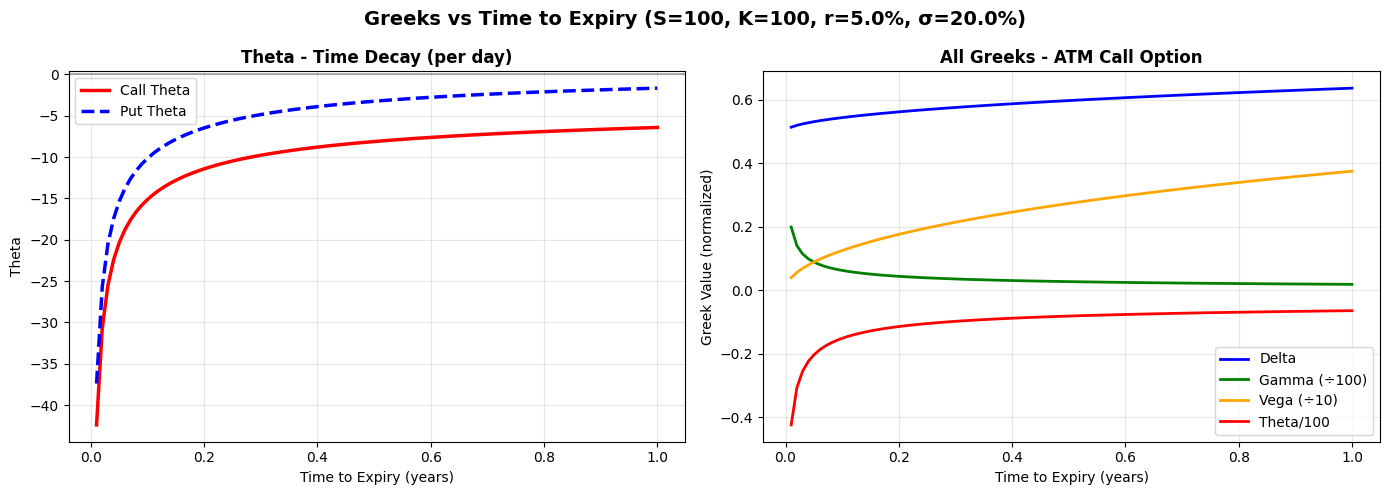


Key Observations on Time Decay:
----------------------------------------------------------------------
• Theta becomes MORE NEGATIVE (accelerates) as expiration approaches
  - Time decay is NOT linear - it accelerates near expiry
  - This is critical for options traders near expiration

• Call vs Put theta at ATM (S=K):
  - At ATM, long calls have negative theta (lose to time decay)
  - At ATM, long puts also have negative theta
  - The effect depends on interest rates: higher rates → call theta less negative

• The 'theta crush' in final weeks:
  - Options lose most of their time value in the last few weeks
  - This is why options are sometimes called 'short-lived assets'


In [7]:
# Task 3 (Part 2): Theta vs Time to Expiry
# Show how theta changes as time to expiry decreases

# Fixed parameters
S = 100  # Fixed at spot = 100 (ATM)
K = 100
r = 0.05
sigma = 0.2

# Range of times to expiry (in years)
times = np.linspace(0.01, 1.0, 100)

# Calculate Greeks at different times for both calls and puts
call_deltas_over_time = [Option.delta(S, K, T, r, sigma, 'call') for T in times]
call_gammas_over_time = [Option.gamma(S, K, T, r, sigma, 'call') for T in times]
call_vegas_over_time = [Option.vega(S, K, T, r, sigma, 'call') for T in times]
call_thetas_over_time = [Option.theta(S, K, T, r, sigma, 'call') for T in times]

put_deltas_over_time = [Option.delta(S, K, T, r, sigma, 'put') for T in times]
put_thetas_over_time = [Option.theta(S, K, T, r, sigma, 'put') for T in times]

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Greeks vs Time to Expiry (S={S}, K={K}, r={r*100}%, σ={sigma*100}%)', 
             fontsize=14, fontweight='bold')

# Theta over time
axes[0].plot(times, call_thetas_over_time, 'r-', linewidth=2.5, label='Call Theta')
axes[0].plot(times, put_thetas_over_time, 'b--', linewidth=2.5, label='Put Theta')
axes[0].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[0].set_title('Theta - Time Decay (per day)', fontweight='bold')
axes[0].set_xlabel('Time to Expiry (years)')
axes[0].set_ylabel('Theta')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Multiple Greeks over time in one plot
axes[1].plot(times, call_deltas_over_time, 'b-', linewidth=2, label='Delta')
axes[1].plot(times, call_gammas_over_time, 'g-', linewidth=2, label='Gamma (÷100)')
axes[1].plot(times, call_vegas_over_time, 'orange', linewidth=2, label='Vega (÷10)')
axes[1].plot(times, np.array(call_thetas_over_time) / 100, 'r-', linewidth=2, label='Theta/100')
axes[1].set_title('All Greeks - ATM Call Option', fontweight='bold')
axes[1].set_xlabel('Time to Expiry (years)')
axes[1].set_ylabel('Greek Value (normalized)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nKey Observations on Time Decay:")
print("-" * 70)
print("• Theta becomes MORE NEGATIVE (accelerates) as expiration approaches")
print("  - Time decay is NOT linear - it accelerates near expiry")
print("  - This is critical for options traders near expiration")
print("\n• Call vs Put theta at ATM (S=K):")
print("  - At ATM, long calls have negative theta (lose to time decay)")
print("  - At ATM, long puts also have negative theta")
print("  - The effect depends on interest rates: higher rates → call theta less negative")
print("\n• The 'theta crush' in final weeks:")
print("  - Options lose most of their time value in the last few weeks")
print("  - This is why options are sometimes called 'short-lived assets'")

## Summary: Greek Letter Risks

Each Greek measures sensitivity to a different risk factor:

**Delta**: Direction risk. Measures how much the option price changes when the underlying price moves by $1. Ranges from 0 to 1 for calls.

**Gamma**: Convexity risk. Measures how quickly delta changes as the underlying price moves. Large gamma means delta is unstable and changes rapidly; small gamma means delta is stable.

**Theta**: Time decay. Measures how much the option loses value as time passes (assuming other factors stay constant). Typically negative for long options (buyer loses value each day), positive for short options (seller gains value each day).

**Vega**: Volatility risk. Measures how much the option price changes when implied volatility changes by 1%. Positive vega means the option gains if volatility rises; negative vega means it loses.